# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test1 probabilities

Notebook equivalent of `tests/2_vacuum/test1_probabilities.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated vacuum-test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "vacuum" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original vacuum test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test1_probabilities"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "2_vacuum" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\2_vacuum\test1_probabilities.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes vacuum-test figures and generated artifacts under `OUTPUT_TEST_ROOT / "vacuum" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "vacuum" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\vacuum\test1_probabilities


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_zero_baseline_identity`

**What is checked:** Zero baseline identity behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: vacuum evolutor must be identity at L=0; nu_e must remain nu_e at L=0.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change.


In [4]:
run_notebook_test(TEST_MODULE.test_zero_baseline_identity)


Running test_zero_baseline_identity ...

Zero-baseline evolutor:
tensor([[ 1.0000e+00+0.0000e+00j,  3.4694e-17+0.0000e+00j,
         -2.7756e-17+2.7756e-17j],
        [ 3.4694e-17+0.0000e+00j,  1.0000e+00+0.0000e+00j,
         -1.6653e-16+1.3878e-17j],
        [-2.7756e-17-2.7756e-17j, -1.6653e-16-1.3878e-17j,
          1.0000e+00+0.0000e+00j]], dtype=torch.complex128)
Final probabilities for initial nu_e: tensor([1.0000e+00, 1.2037e-33, 1.5407e-33], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_zero_baseline_identity


## Test: `test_probability_matrix_conservation`

**What is checked:** Probability matrix conservation behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Probability matrix must have shape (NE, 3, 3); Probabilities must be finite; Each initial flavour column must sum to one; Each final flavour row must sum to one.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; normalization failures often point to probability conservation or broadcasting issues.


In [5]:
run_notebook_test(TEST_MODULE.test_probability_matrix_conservation)


Running test_probability_matrix_conservation ...

Probability matrices P[final flavour, initial flavour]:
tensor([[[0.9362, 0.0276, 0.0362],
         [0.0298, 0.9158, 0.0544],
         [0.0340, 0.0566, 0.9094]],

        [[0.9495, 0.0123, 0.0382],
         [0.0312, 0.4435, 0.5253],
         [0.0193, 0.5443, 0.4365]],

        [[0.9569, 0.0197, 0.0235],
         [0.0253, 0.5191, 0.4556],
         [0.0178, 0.4612, 0.5209]],

        [[0.9953, 0.0024, 0.0023],
         [0.0026, 0.9481, 0.0494],
         [0.0021, 0.0496, 0.9483]]], dtype=torch.float64)
Column sums, fixed initial flavour: tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]], dtype=torch.float64)
Row sums, fixed final flavour: tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]], dtype=torch.float64)
--------------------------------------------------------------

## Test: `test_coherent_flavour_probabilities_sum_to_one`

**What is checked:** Coherent flavour probabilities sum to one behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Batched coherent probabilities must have shape (NE, 3); coherent final probabilities must sum to one.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; normalization failures often point to probability conservation or broadcasting issues.


In [6]:
run_notebook_test(TEST_MODULE.test_coherent_flavour_probabilities_sum_to_one)


Running test_coherent_flavour_probabilities_sum_to_one ...

coherent initial nu_mu probabilities:
tensor([[0.0015, 0.0753, 0.9232],
        [0.0060, 0.9828, 0.0112],
        [0.0209, 0.2001, 0.7790],
        [0.0330, 0.0094, 0.9576],
        [0.0311, 0.1586, 0.8104],
        [0.0261, 0.3321, 0.6418],
        [0.0213, 0.4722, 0.5064]], dtype=torch.float64)
Probability sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_coherent_flavour_probabilities_sum_to_one


## Test: `test_mass_basis_weights_are_normalized`

**What is checked:** Mass basis weights are normalized behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Mass-basis result must have shape (NL, 3); Mass-basis probabilities must be non-negative; Mass-basis probabilities must sum to one.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; normalization failures often point to probability conservation or broadcasting issues.


In [7]:
run_notebook_test(TEST_MODULE.test_mass_basis_weights_are_normalized)


Running test_mass_basis_weights_are_normalized ...

Final flavour probabilities from incoherent mass weights:
tensor([[0.2370, 0.3778, 0.3852],
        [0.2370, 0.3778, 0.3852],
        [0.2370, 0.3778, 0.3852],
        [0.2370, 0.3778, 0.3852]], dtype=torch.float64)
Probability sums: tensor([1.0000, 1.0000, 1.0000, 1.0000], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_mass_basis_weights_are_normalized


## Test: `test_antineutrino_equals_neutrino_when_delta_zero`

**What is checked:** Antineutrino equals neutrino when delta zero behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: nu and antinu vacuum probabilities must match when delta=0.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; sign or CP-phase convention changes can affect neutrino-antineutrino comparisons.


In [8]:
run_notebook_test(TEST_MODULE.test_antineutrino_equals_neutrino_when_delta_zero)


Running test_antineutrino_equals_neutrino_when_delta_zero ...

Neutrino probabilities at delta=0:
tensor([[0.8022, 0.1536, 0.0442],
        [0.9087, 0.0320, 0.0593],
        [0.9112, 0.0432, 0.0456],
        [0.9787, 0.0123, 0.0090]], dtype=torch.float64)
Antineutrino probabilities at delta=0:
tensor([[0.8022, 0.1536, 0.0442],
        [0.9087, 0.0320, 0.0593],
        [0.9112, 0.0432, 0.0456],
        [0.9787, 0.0123, 0.0090]], dtype=torch.float64)
Max absolute difference: 0.0
------------------------------------------------------------------------------------------
PASSED: test_antineutrino_equals_neutrino_when_delta_zero


## Test: `test_compare_with_legacy_pvacuum`

**What is checked:** Compare with legacy pvacuum behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Torch vacuum probabilities must match legacy peanuts for neutrinos.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; the optional legacy `peanuts` package may be unavailable or may have changed conventions.


In [9]:
run_notebook_test(TEST_MODULE.test_compare_with_legacy_pvacuum)


Running test_compare_with_legacy_pvacuum ...

Torch vacuum probabilities compared with legacy peanuts:

Case: flavour nu_e
torch   : tensor([0.9346, 0.0394, 0.0260], dtype=torch.float64)
legacy  : tensor([0.9346, 0.0394, 0.0260], dtype=torch.float64)
abs diff: tensor([4.4409e-16, 9.7145e-16, 7.0430e-16], dtype=torch.float64)
max abs : 9.714451e-16

Case: flavour nu_mu
torch   : tensor([0.0314, 0.0042, 0.9644], dtype=torch.float64)
legacy  : tensor([0.0314, 0.0042, 0.9644], dtype=torch.float64)
abs diff: tensor([1.5474e-15, 2.0817e-17, 2.9976e-15], dtype=torch.float64)
max abs : 2.997602e-15

Case: mass weights
torch   : tensor([0.2370, 0.3778, 0.3852], dtype=torch.float64)
legacy  : tensor([0.2370, 0.3778, 0.3852], dtype=torch.float64)
abs diff: tensor([2.2204e-15, 2.4980e-15, 2.7200e-15], dtype=torch.float64)
max abs : 2.720046e-15

Global maximum legacy comparison error: 2.997602e-15
------------------------------------------------------------------------------------------
PASSED: te

## Plot: `plot_vacuum_probabilities_vs_baseline`

**What is checked:** Vacuum probabilities vs baseline behavior and numerical consistency.

**Expected result:** The expected result is that the plot function writes vacuum_probabilities_vs_baseline.png to `OUTPUT_DIR` and displays it inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_vacuum_probabilities_vs_baseline`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `vacuum_probabilities_vs_baseline.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_vacuum_probabilities_vs_baseline ...
Saved plot: V:\output\test\vacuum\test1_probabilities\plot_vacuum_probabilities_vs_baseline_figure_001.png


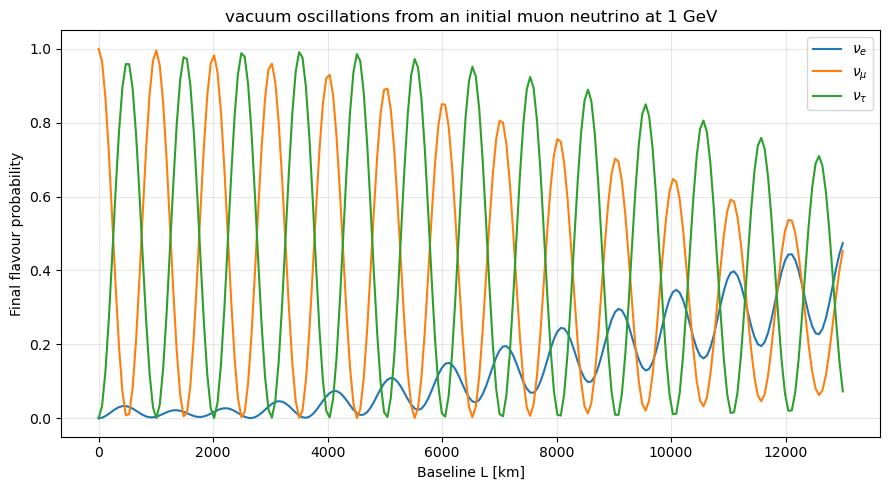

------------------------------------------------------------------------------------------
PASSED: plot_vacuum_probabilities_vs_baseline


In [10]:
run_notebook_test(TEST_MODULE.plot_vacuum_probabilities_vs_baseline)


## Plot: `plot_neutrino_antineutrino_comparison`

**What is checked:** Neutrino antineutrino comparison behavior and numerical consistency.

**Expected result:** The expected result is that the plot function writes vacuum_neutrino_antineutrino_comparison.png to `OUTPUT_DIR` and displays it inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; sign or CP-phase convention changes can affect neutrino-antineutrino comparisons; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_neutrino_antineutrino_comparison`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `vacuum_neutrino_antineutrino_comparison.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_neutrino_antineutrino_comparison ...
Saved plot: V:\output\test\vacuum\test1_probabilities\plot_neutrino_antineutrino_comparison_figure_001.png


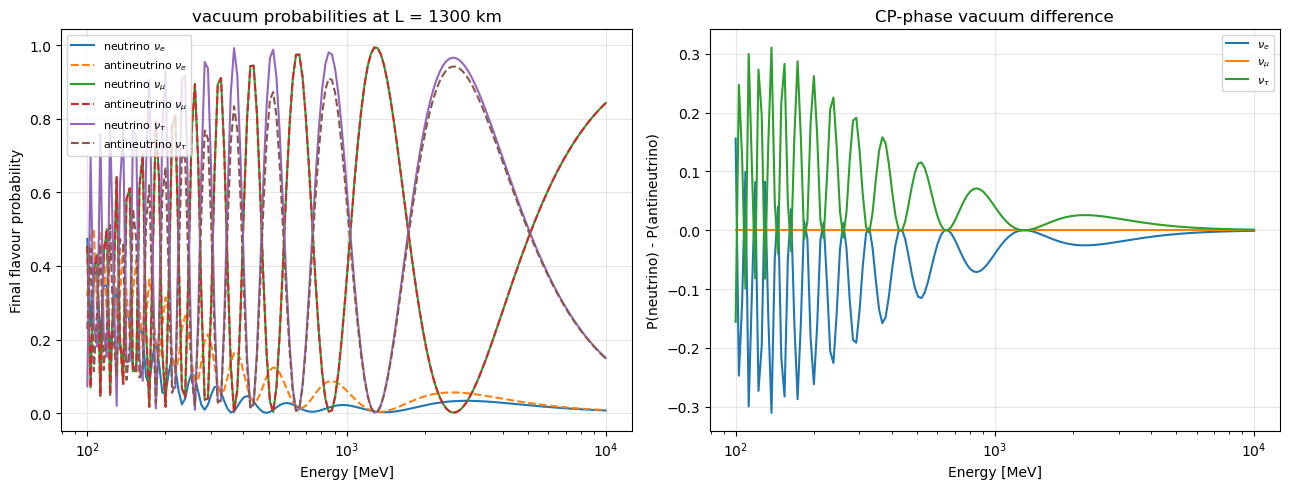

------------------------------------------------------------------------------------------
PASSED: plot_neutrino_antineutrino_comparison


In [11]:
run_notebook_test(TEST_MODULE.plot_neutrino_antineutrino_comparison)
